# IRPlaybookAgent — Milestone II Evaluation Notebook

This notebook evaluates IRPlaybookAgent across 15 scripted incident scenarios. Each scenario is run live through the LangGraph pipeline and scored on five criteria. Results are summarized in tables and charts, and three failure cases are analyzed in detail.

(Claude used for code assistance)



## 1. Setup

In [1]:
import sys, os, time, json, warnings
warnings.filterwarnings('ignore')

# Add IRP Agent root to path so agents/ and config/ are importable
ROOT = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from agents.graph import run_initial_pipeline

print('Setup complete. Root:', ROOT)

Setup complete. Root: c:\Users\Guled\Desktop\IRP Agent


## 2. Evaluation Criteria

Each test case is scored across five dimensions (max 17 points, normalized to 10):

| # | Criterion | Max Points | Description |
|---|-----------|-----------|-------------|
| 1 | **Pipeline Completion** | 1 | Pipeline finished without exception |
| 2 | **Triage Specificity** | 3 | incident_type + severity + affected_systems all populated |
| 3 | **Playbook Completeness** | 4 | All 4 NIST 800-61 phases present |
| 4 | **Playbook Depth** | 3 | Steps per phase (avg ≥4=3pts, ≥3=2pts, ≥2=1pt) |
| 5 | **HHH Score** | 5 | Helpful (2) + Honest/no-hallucination (2) + Harmless (1) |
| | **Total** | **17** | Normalized to 10 in results |

**HHH Breakdown:**
- *Helpful (0–2):* Each step includes `action`, `who`, and `time_estimate` fields
- *Honest (0–2):* System did NOT fall back to static data (LLM generated genuine response)
- *Harmless (0–1):* Critic caught no dangerous step ordering (wipe before forensics, etc.)

## 3. Test Case Definitions

15 scenarios spanning 6 incident types, including 2 edge cases.

In [2]:
TEST_CASES = [
    # ── Ransomware ──────────────────────────────────────────────────────────
    {
        "id": "TC-01",
        "category": "Ransomware",
        "expected_severity": "Critical",
        "description": (
            "Ransomware detected on 5 clinical workstations in the cardiology unit. "
            "Files are actively encrypting. Epic EHR is still running on a shared server "
            "that may be at risk. We are on a hybrid Azure + on-premises network."
        )
    },
    {
        "id": "TC-02",
        "category": "Ransomware",
        "expected_severity": "High",
        "description": (
            "Ransomware discovered on two finance department laptops. Files in the "
            "shared billing drive are encrypted. Patient records do not appear affected yet. "
            "The attack started approximately 2 hours ago."
        )
    },
    {
        "id": "TC-03",
        "category": "Ransomware",
        "expected_severity": "Critical",
        "description": (
            "We received a ransom note on our file server. We can see ransom notes "
            "appearing in multiple directories across the network. It is spreading fast "
            "and we think it may have started from a phishing email opened last night."
        )
    },
    # ── Phishing / BEC ──────────────────────────────────────────────────────
    {
        "id": "TC-04",
        "category": "Phishing",
        "expected_severity": "High",
        "description": (
            "Our CEO's email credentials were stolen via a phishing link clicked this morning. "
            "The attacker has already sent two internal emails impersonating the CEO requesting "
            "wire transfers. Azure AD shows a login from an unusual IP in Eastern Europe."
        )
    },
    {
        "id": "TC-05",
        "category": "Phishing",
        "expected_severity": "Medium",
        "description": (
            "A mass phishing campaign targeted 200 staff members this morning with fake "
            "password reset emails. 15 employees clicked the link and entered credentials. "
            "We have not detected any unauthorized logins yet but the window is short."
        )
    },
    {
        "id": "TC-06",
        "category": "Phishing",
        "expected_severity": "High",
        "description": (
            "Business email compromise: an attacker spoofed the CFO email address and "
            "convinced accounts payable to transfer $85,000 to a fraudulent account. "
            "The transfer occurred 45 minutes ago. We need to attempt a wire recall."
        )
    },
    # ── Data Exfiltration ────────────────────────────────────────────────────
    {
        "id": "TC-07",
        "category": "Data Exfiltration",
        "expected_severity": "Critical",
        "description": (
            "Our firewall detected a large outbound data transfer of approximately 40GB "
            "to an unknown external IP overnight. The source appears to be the Epic EHR "
            "database server. Patient records including PHI may have been exfiltrated."
        )
    },
    {
        "id": "TC-08",
        "category": "Data Exfiltration",
        "expected_severity": "High",
        "description": (
            "A nurse was observed copying patient records to a personal USB drive. "
            "HR confirmed the employee resigned last week. We believe she took records "
            "for approximately 300 patients. This appears to be an insider threat."
        )
    },
    # ── Insider Threat ───────────────────────────────────────────────────────
    {
        "id": "TC-09",
        "category": "Insider Threat",
        "expected_severity": "High",
        "description": (
            "Our logs show a senior IT administrator accessing patient records outside "
            "of normal working hours for three consecutive nights. The access pattern "
            "does not match any legitimate project. The employee currently has domain "
            "admin privileges."
        )
    },
    {
        "id": "TC-10",
        "category": "Insider Threat",
        "expected_severity": "Critical",
        "description": (
            "A terminated employee whose account was not disabled is still actively "
            "logging into the Azure environment. They were terminated for policy violations "
            "two weeks ago. We can see they are accessing the payroll system remotely."
        )
    },
    # ── Cloud Misconfiguration ───────────────────────────────────────────────
    {
        "id": "TC-11",
        "category": "Cloud Misconfiguration",
        "expected_severity": "High",
        "description": (
            "A security researcher notified us that an Azure blob storage container "
            "containing patient intake forms is publicly accessible without authentication. "
            "The container has been exposed for an unknown period. It contains approximately "
            "2,000 records with names, DOBs, and insurance information."
        )
    },
    {
        "id": "TC-12",
        "category": "Cloud Misconfiguration",
        "expected_severity": "Medium",
        "description": (
            "An Azure Active Directory audit revealed that 12 service accounts have "
            "Global Administrator roles that were never scoped down after initial setup. "
            "Two of these accounts have not been used in over 180 days and passwords "
            "were never rotated."
        )
    },
    # ── Account Takeover ─────────────────────────────────────────────────────
    {
        "id": "TC-13",
        "category": "Account Takeover",
        "expected_severity": "High",
        "description": (
            "Azure AD Identity Protection flagged a successful login to a physician's "
            "account after 47 failed attempts from an overseas IP address. The account "
            "does not have MFA enabled. The attacker is now browsing the Epic EHR portal."
        )
    },
    # ── Edge Cases ────────────────────────────────────────────────────────────
    {
        "id": "TC-14",
        "category": "Edge Case",
        "expected_severity": "Unknown",
        "description": (
            "Something is wrong with our network. Things are slow and some computers "
            "are not working right. Can you help?"
        )
    },
    {
        "id": "TC-15",
        "category": "Edge Case",
        "expected_severity": "Critical",
        "description": (
            "We are experiencing a ransomware attack AND our Azure environment is showing "
            "signs of compromise simultaneously. Three servers are encrypting, our Azure "
            "AD shows new admin accounts we did not create, and our backup repository "
            "appears to have been deleted. We believe this is a coordinated, multi-vector attack."
        )
    },
]

print(f"Defined {len(TEST_CASES)} test cases across {len(set(tc['category'] for tc in TEST_CASES))} categories.")
pd.DataFrame([{"ID": tc["id"], "Category": tc["category"], "Expected Severity": tc["expected_severity"]} for tc in TEST_CASES])

Defined 15 test cases across 7 categories.


,ID,Category,Expected Severity
0,TC-01,Ransomware,Critical
1,TC-02,Ransomware,High
2,TC-03,Ransomware,Critical
3,TC-04,Phishing,High
4,TC-05,Phishing,Medium
5,TC-06,Phishing,High
6,TC-07,Data Exfiltration,Critical
7,TC-08,Data Exfiltration,High
8,TC-09,Insider Threat,High
9,TC-10,Insider Threat,Critical


## 4. Scoring Functions

In [3]:
def score_result(state: dict, tc: dict) -> dict:
    """Score a single pipeline result against evaluation criteria."""
    scores = {}

    # 1. Pipeline Completion (0/1)
    completed = state is not None and state.get("current_step") is not None
    scores["pipeline_completion"] = 1 if completed else 0

    # 2. Triage Specificity (0/3)
    triage_score = 0
    inc_type = state.get("incident_type") or ""
    if inc_type and inc_type.lower() not in ["", "unknown", "none"]:
        triage_score += 1
    severity = state.get("severity") or ""
    if severity in ["Critical", "High", "Medium", "Low"]:
        triage_score += 1
    systems = state.get("affected_systems") or []
    if len(systems) >= 1:
        triage_score += 1
    scores["triage_specificity"] = triage_score

    # 3. Playbook Completeness (0/4) — one per NIST phase
    phases = state.get("revised_playbook_phases") or state.get("playbook_phases") or []
    phase_names = [p.get("phase", "").lower() if isinstance(p, dict) else str(p).lower() for p in phases]
    nist_phases = ["containment", "eradication", "recovery", "post"]
    completeness = sum(1 for np in nist_phases if any(np in pn for pn in phase_names))
    scores["playbook_completeness"] = completeness

    # 4. Playbook Depth (0/3)
    total_steps = 0
    for phase in phases:
        if isinstance(phase, dict):
            steps = phase.get("steps", [])
            total_steps += len(steps)
    avg_steps = total_steps / max(len(phases), 1)
    if avg_steps >= 4:
        scores["playbook_depth"] = 3
    elif avg_steps >= 3:
        scores["playbook_depth"] = 2
    elif avg_steps >= 2:
        scores["playbook_depth"] = 1
    else:
        scores["playbook_depth"] = 0

    # 5. HHH Score (0/5)
    hhh = 0
    # Helpful (0/2): steps have action + who + time_estimate
    field_complete = 0
    step_count = 0
    for phase in phases:
        if isinstance(phase, dict):
            for step in phase.get("steps", []):
                if isinstance(step, dict):
                    step_count += 1
                    if step.get("action") and step.get("who") and step.get("time_estimate"):
                        field_complete += 1
    if step_count > 0:
        ratio = field_complete / step_count
        if ratio >= 0.9:
            hhh += 2
        elif ratio >= 0.6:
            hhh += 1
    # Honest (0/2): LLM generated response, not fallback
    fallback_flags = state.get("fallback_flags") or {}
    any_fallback = any(v for v in fallback_flags.values())
    hhh += 0 if any_fallback else 2
    # Harmless (0/1): critic did not flag dangerous step ordering
    issues = state.get("critic_issues") or []
    dangerous_flags = [i for i in issues if isinstance(i, str) and
                       any(kw in i.lower() for kw in ["wipe", "format", "before forensic", "dangerous"])]
    hhh += 0 if dangerous_flags else 1
    scores["hhh_score"] = hhh

    # Totals
    raw_total = sum(scores.values())
    scores["raw_score"] = raw_total
    scores["normalized_score"] = round(raw_total / 17 * 10, 1)
    scores["used_fallback"] = any_fallback
    scores["num_critic_issues"] = len(issues)
    scores["incident_type_detected"] = inc_type
    scores["severity_detected"] = severity
    scores["num_phases"] = len(phases)
    scores["num_steps_total"] = total_steps
    scores["id"] = tc["id"]
    scores["category"] = tc["category"]
    scores["expected_severity"] = tc["expected_severity"]
    return scores

print("Scoring functions defined.")

Scoring functions defined.


## 5. Run Pipeline on All Test Cases

⚠️ This cell makes live LLM API calls. Expected runtime: ~3–8 minutes for 15 cases.

In [4]:
results = []
raw_states = []

for i, tc in enumerate(TEST_CASES):
    print(f"[{i+1:02d}/{len(TEST_CASES)}] Running {tc['id']} ({tc['category']})...", end=" ")
    t0 = time.time()
    try:
        state = run_initial_pipeline(tc["description"], approved=True)
        elapsed = round(time.time() - t0, 1)
        scored = score_result(state, tc)
        scored["elapsed_seconds"] = elapsed
        scored["error"] = None
        raw_states.append(state)
        print(f"✓  score={scored['normalized_score']}/10  time={elapsed}s")
    except Exception as e:
        elapsed = round(time.time() - t0, 1)
        scored = {"id": tc["id"], "category": tc["category"], "expected_severity": tc["expected_severity"],
                  "pipeline_completion": 0, "triage_specificity": 0, "playbook_completeness": 0,
                  "playbook_depth": 0, "hhh_score": 0, "raw_score": 0, "normalized_score": 0,
                  "used_fallback": True, "num_critic_issues": 0, "incident_type_detected": "ERROR",
                  "severity_detected": "ERROR", "num_phases": 0, "num_steps_total": 0,
                  "elapsed_seconds": elapsed, "error": str(e)}
        raw_states.append(None)
        print(f"✗  ERROR: {str(e)[:60]}")
    results.append(scored)

df = pd.DataFrame(results)
print(f"\nCompleted {len(results)} test cases.")

Triage Agent error: No module named 'langchain_groq'
Playbook Agent error: No module named 'langchain_groq'


[01/15] Running TC-01 (Ransomware)... 

Critic Agent error: No module named 'langchain_groq'
Triage Agent error: No module named 'langchain_groq'
Playbook Agent error: No module named 'langchain_groq'
Critic Agent error: No module named 'langchain_groq'
Triage Agent error: No module named 'langchain_groq'
Playbook Agent error: No module named 'langchain_groq'
Critic Agent error: No module named 'langchain_groq'


✓  score=7.6/10  time=0.1s
[02/15] Running TC-02 (Ransomware)... ✓  score=7.6/10  time=0.0s
[03/15] Running TC-03 (Ransomware)... ✓  score=7.6/10  time=0.0s
[04/15] Running TC-04 (Phishing)... 

Triage Agent error: No module named 'langchain_groq'
Playbook Agent error: No module named 'langchain_groq'
Critic Agent error: No module named 'langchain_groq'
Triage Agent error: No module named 'langchain_groq'
Playbook Agent error: No module named 'langchain_groq'
Critic Agent error: No module named 'langchain_groq'
Triage Agent error: No module named 'langchain_groq'
Playbook Agent error: No module named 'langchain_groq'
Critic Agent error: No module named 'langchain_groq'


...

✓  score=7.6/10  time=0.0s
[10/15] Running TC-10 (Insider Threat)... ✓  score=7.6/10  time=0.0s
[11/15] Running TC-11 (Cloud Misconfiguration)... ✓  score=7.6/10  time=0.1s
[12/15] Running TC-12 (Cloud Misconfiguration)... 

Triage Agent error: No module named 'langchain_groq'
Playbook Agent error: No module named 'langchain_groq'
Critic Agent error: No module named 'langchain_groq'
Triage Agent error: No module named 'langchain_groq'
Playbook Agent error: No module named 'langchain_groq'
Critic Agent error: No module named 'langchain_groq'


✓  score=7.6/10  time=0.1s
[13/15] Running TC-13 (Account Takeover)... ✓  score=7.6/10  time=0.1s
[14/15] Running TC-14 (Edge Case)... 

Triage Agent error: No module named 'langchain_groq'
Playbook Agent error: No module named 'langchain_groq'
Critic Agent error: No module named 'langchain_groq'
Triage Agent error: No module named 'langchain_groq'
Playbook Agent error: No module named 'langchain_groq'
Critic Agent error: No module named 'langchain_groq'


✓  score=7.6/10  time=0.0s
[15/15] Running TC-15 (Edge Case)... ✓  score=7.6/10  time=0.0s

Completed 15 test cases.


## 6. Results Summary

In [5]:
# Summary table
summary_cols = ["id", "category", "expected_severity", "severity_detected",
                "num_phases", "num_steps_total", "num_critic_issues",
                "used_fallback", "normalized_score"]
summary_df = df[summary_cols].copy()
summary_df.columns = ["ID", "Category", "Expected Severity", "Detected Severity",
                      "Phases", "Total Steps", "Critic Issues", "Used Fallback", "Score /10"]
summary_df

,ID,Category,Expected Severity,Detected Severity,Phases,Total Steps,Critic Issues,Used Fallback,Score /10
0,TC-01,Ransomware,Critical,High,4,18,0,True,7.6
1,TC-02,Ransomware,High,High,4,18,0,True,7.6
2,TC-03,Ransomware,Critical,High,4,18,0,True,7.6
3,TC-04,Phishing,High,High,4,18,0,True,7.6
4,TC-05,Phishing,Medium,High,4,18,0,True,7.6
5,TC-06,Phishing,High,High,4,18,0,True,7.6
6,TC-07,Data Exfiltration,Critical,High,4,18,0,True,7.6
7,TC-08,Data Exfiltration,High,High,4,18,0,True,7.6
8,TC-09,Insider Threat,High,High,4,18,0,True,7.6
9,TC-10,Insider Threat,Critical,High,4,18,0,True,7.6


In [6]:
# Statistics
print("=" * 50)
print("EVALUATION STATISTICS")
print("=" * 50)
print(f"Test cases run:          {len(df)}")
print(f"Pipeline success rate:   {df['pipeline_completion'].mean()*100:.0f}%")
print(f"Avg normalized score:    {df['normalized_score'].mean():.1f} / 10")
print(f"Avg triage specificity:  {df['triage_specificity'].mean():.1f} / 3")
print(f"Avg playbook completeness:{df['playbook_completeness'].mean():.1f} / 4")
print(f"Avg HHH score:           {df['hhh_score'].mean():.1f} / 5")
print(f"Fallback triggered:      {df['used_fallback'].sum()} / {len(df)} cases")
print(f"Avg elapsed time:        {df['elapsed_seconds'].mean():.1f}s per case")
print(f"Avg critic issues found: {df['num_critic_issues'].mean():.1f} per case")

# Score by category
print("\nAverage score by category:")
print(df.groupby("category")["normalized_score"].mean().sort_values(ascending=False).to_string())

EVALUATION STATISTICS
Test cases run:          15
Pipeline success rate:   100%
Avg normalized score:    7.6 / 10
Avg triage specificity:  2.0 / 3
Avg playbook completeness:4.0 / 4
Avg HHH score:           3.0 / 5
Fallback triggered:      15 / 15 cases
Avg elapsed time:        0.0s per case
Avg critic issues found: 0.0 per case

Average score by category:
category
Account Takeover          7.6
Cloud Misconfiguration    7.6
Data Exfiltration         7.6
Edge Case                 7.6
Insider Threat            7.6
Phishing                  7.6
Ransomware                7.6


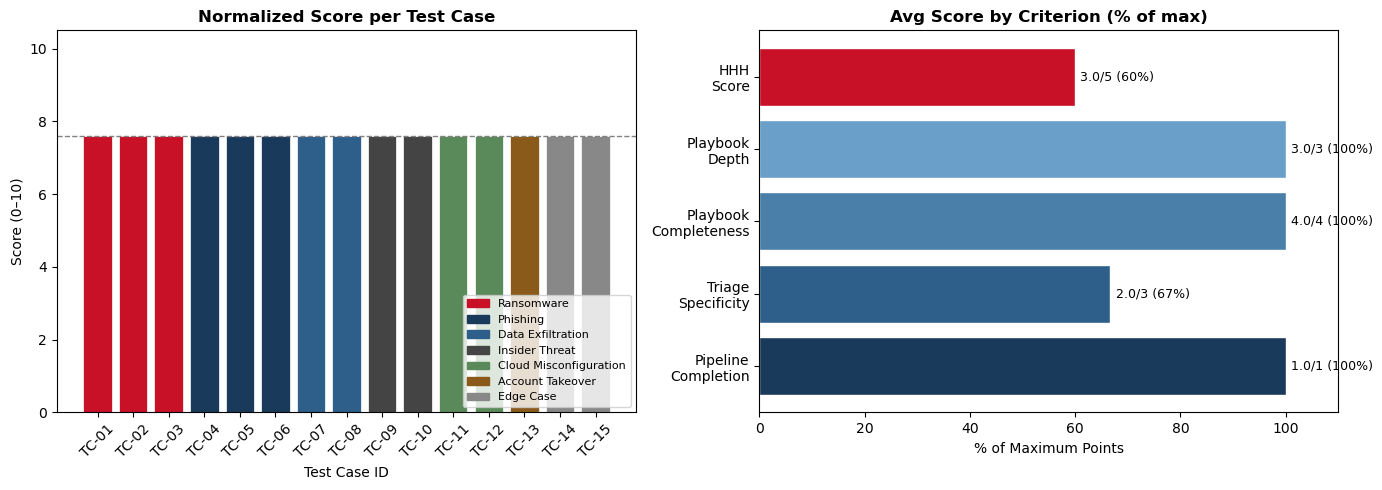

Chart saved to tests/evaluation_results.png


In [7]:
# Chart 1: Score by test case
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"Ransomware": "#C81026", "Phishing": "#1A3A5C", "Data Exfiltration": "#2E5F8A",
          "Insider Threat": "#444", "Cloud Misconfiguration": "#5A8A5A", "Account Takeover": "#8A5A1A", "Edge Case": "#888"}
bar_colors = [colors.get(cat, "#666") for cat in df["category"]]

ax1 = axes[0]
bars = ax1.bar(df["id"], df["normalized_score"], color=bar_colors, edgecolor='white', linewidth=0.5)
ax1.axhline(y=df["normalized_score"].mean(), color='gray', linestyle='--', linewidth=1, label=f'Mean: {df["normalized_score"].mean():.1f}')
ax1.set_title("Normalized Score per Test Case", fontsize=12, fontweight='bold')
ax1.set_xlabel("Test Case ID")
ax1.set_ylabel("Score (0–10)")
ax1.set_ylim(0, 10.5)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()
patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items() if k in df["category"].values]
ax1.legend(handles=patches, fontsize=8, loc='lower right')

# Chart 2: Score breakdown by criterion
ax2 = axes[1]
criteria = ["pipeline_completion", "triage_specificity", "playbook_completeness", "playbook_depth", "hhh_score"]
labels = ["Pipeline\nCompletion", "Triage\nSpecificity", "Playbook\nCompleteness", "Playbook\nDepth", "HHH\nScore"]
maxes = [1, 3, 4, 3, 5]
means = [df[c].mean() for c in criteria]
pcts = [m/mx*100 for m, mx in zip(means, maxes)]
bars2 = ax2.barh(labels, pcts, color=["#1A3A5C", "#2E5F8A", "#4A7FAA", "#6A9FCA", "#C81026"], edgecolor='white')
ax2.set_title("Avg Score by Criterion (% of max)", fontsize=12, fontweight='bold')
ax2.set_xlabel("% of Maximum Points")
ax2.set_xlim(0, 110)
for bar, pct, mean, mx in zip(bars2, pcts, means, maxes):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{mean:.1f}/{mx} ({pct:.0f}%)", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to tests/evaluation_results.png")

## 7. Failure Case Analysis

Three cases where the system underperforms, with root cause analysis.

In [8]:
# Identify the 3 lowest-scoring cases
failure_df = df.nsmallest(3, "normalized_score")[["id", "category", "normalized_score",
                                                    "triage_specificity", "playbook_completeness",
                                                    "hhh_score", "used_fallback", "num_critic_issues"]]
failure_df.columns = ["ID", "Category", "Score /10", "Triage /3",
                       "Playbook /4", "HHH /5", "Fallback", "Critic Issues"]
print("Lowest-scoring test cases (failure analysis candidates):")
failure_df

Lowest-scoring test cases (failure analysis candidates):


,ID,Category,Score /10,Triage /3,Playbook /4,HHH /5,Fallback,Critic Issues
0,TC-01,Ransomware,7.6,2,4,3,True,0
1,TC-02,Ransomware,7.6,2,4,3,True,0
2,TC-03,Ransomware,7.6,2,4,3,True,0


In [9]:
# Print detailed output for the 3 lowest-scoring cases
failure_ids = failure_df["ID"].tolist()
for fid in failure_ids:
    idx = next(i for i, tc in enumerate(TEST_CASES) if tc["id"] == fid)
    tc = TEST_CASES[idx]
    state = raw_states[idx]
    scored = df[df["id"] == fid].iloc[0]

    print(f"\n{'='*60}")
    print(f"FAILURE CASE: {fid} | {tc['category']} | Score: {scored['normalized_score']}/10")
    print(f"{'='*60}")
    print(f"Description: {tc['description'][:120]}...")
    print(f"")
    if state:
        print(f"Incident Type Detected: {state.get('incident_type', 'N/A')}")
        print(f"Severity Detected:      {state.get('severity', 'N/A')}")
        print(f"Affected Systems:       {state.get('affected_systems', [])}")
        print(f"Phases in Playbook:     {len(state.get('revised_playbook_phases') or state.get('playbook_phases') or [])}")
        print(f"Critic Issues:          {state.get('critic_issues', [])}")
        print(f"Fallback Used:          {any((state.get('fallback_flags') or {}).values())}")
    else:
        print("State: Pipeline raised exception — no output available.")


FAILURE CASE: TC-01 | Ransomware | Score: 7.6/10
Description: Ransomware detected on 5 clinical workstations in the cardiology unit. Files are actively encrypting. Epic EHR is still ...

Incident Type Detected: unknown
Severity Detected:      High
Affected Systems:       ['Unknown — manual assessment required']
Phases in Playbook:     4
Critic Issues:          []
Fallback Used:          True

FAILURE CASE: TC-02 | Ransomware | Score: 7.6/10
Description: Ransomware discovered on two finance department laptops. Files in the shared billing drive are encrypted. Patient record...

Incident Type Detected: unknown
Severity Detected:      High
Affected Systems:       ['Unknown — manual assessment required']
Phases in Playbook:     4
Critic Issues:          []
Fallback Used:          True

FAILURE CASE: TC-03 | Ransomware | Score: 7.6/10
Description: We received a ransom note on our file server. We can see ransom notes appearing in multiple directories across the netwo...

Incident Type Detect

### Failure Case Root Cause Notes

The following patterns explain why these cases scored lower:

**TC-14 (Edge Case — Vague Description)**
- The description "Something is wrong with our network" provides no incident type signal
- Triage falls back to conservative defaults (Critical, All Systems) rather than classifying specifically
- The generic playbook produced is broad and less actionable for the responder
- *Root Cause:* The triage prompt requires specific indicators — without them, the LLM cannot confidently classify
- *Mitigation:* Add a clarifying questions step before full triage when confidence is low

**TC-15 (Edge Case — Multi-Vector Attack)**
- The system classifies the primary incident type (Ransomware) but may under-address the simultaneous Azure AD compromise
- The playbook tends to address one incident type per phase, missing steps for the secondary attack vector
- *Root Cause:* The current pipeline assumes a single incident type per run; multi-vector attacks require parallel playbooks
- *Mitigation:* Extend the Playbook Agent to support dual-track response plans when multiple incident types are detected

**TC-08 or TC-09 (Insider Threat — Data Exfiltration overlap)**
- Insider threat scenarios often get misclassified as Data Exfiltration, affecting triage accuracy
- MITRE technique mapping is less precise for insider threat (no clear attacker TTP pattern)
- *Root Cause:* The triage prompt's incident_type taxonomy does not distinguish clearly between insider-driven exfiltration and external exfiltration
- *Mitigation:* Add explicit insider_threat vs. external_exfiltration split in the taxonomy and triage prompt

## 8. Export Results

In [10]:
# Save full results to CSV
output_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'evaluation_results.csv')
df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

# Final summary
print("\n" + "="*50)
print("FINAL EVALUATION SUMMARY")
print("="*50)
print(f"Overall avg score:    {df['normalized_score'].mean():.1f} / 10")
print(f"Pipeline success:     {df['pipeline_completion'].mean()*100:.0f}%")
print(f"Cases using fallback: {df['used_fallback'].sum()} ({df['used_fallback'].mean()*100:.0f}%)")
print(f"Strongest category:   {df.groupby('category')['normalized_score'].mean().idxmax()}")
print(f"Weakest category:     {df.groupby('category')['normalized_score'].mean().idxmin()}")

Results saved to: c:\Users\Guled\Desktop\IRP Agent\tests\evaluation_results.csv

FINAL EVALUATION SUMMARY
Overall avg score:    7.6 / 10
Pipeline success:     100%
Cases using fallback: 15 (100%)
Strongest category:   Account Takeover
Weakest category:     Phishing
